# A signal-safe cosmic veto: third-muon collinearity and vertex consistency

**The cosmic problem, and why MC can only answer half of it.** Cosmic-ray muons
crossing the detector are reconstructed as a back-to-back pair and can enter
the muon channels. Their *rejection* cannot be estimated from simulation --
Monte Carlo contains no cosmics -- so the veto's rejection power is a
data-control-region measurement, deferred to the continuation. What MC *can*
and must answer is the other half: **does the veto destroy signal?** A cosmic
veto that also removes the dark-photon signal is useless, and the obvious
version does exactly that.

**Why the naive cut fails (notebook 06).** A plain "the two leading lepton-jets
are back-to-back" cut (cos alpha near -1) tags cosmics -- but in 4mu the two
signal dark-photon lepton-jets are *themselves* back-to-back, so the cut
self-vetoes signal. Notebook 06 measured this and set the plain cut aside.

**The signal-safe veto.** The fix is to tag the cosmic topology without using
the two signal lepton-jets against each other:

* **Third-muon collinearity tag.** Require a back-to-back partner (cos alpha
  < -0.98) for the leading mu-LJ drawn from the pool of event muons *not inside
  the two leading lepton-jets*. A cosmic's second leg is such an extra muon; a
  signal event's two dark-photon LJs are excluded from the pool, so the signal
  is not tagged by its own back-to-back-ness.
* **Vertex-consistency (collinearity) variant.** For the residual blind spot --
  a two-leg cosmic reconstructed as exactly the two leading LJs with no third
  muon -- the design note `COSMIC_VERTEX_CONSISTENCY.md` proposes a geometric
  discriminant `coll = |dr_hat . p_hat|` from the DSA-muon reference points:
  a cosmic's two legs lie on one straight line (coll -> 1), while two muons
  from a common vertex diverge (coll < 1) *regardless of how displaced the
  vertex is*. This makes "large separation" cosmic-specific and spares
  displaced signal, which a raw separation cut cannot.

This notebook measures the signal cost of the third-muon collinearity tag on
the full signal grid. It reads only signal MC.

In [1]:
import glob, re
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import coffea.util as cu

plt.style.use(hep.style.CMS)

# MC-ONLY: the cosmic-tag histograms from a small signal-MC pass, staged to the
# MC-only handoff directory. Regenerate with the tag-filling pass documented in
# the series README (signal MC only; no collision data).
MCDIR = "/uscms_data/d3/murtazas/abcd_plane_study_pairres_local"
COSTAG = MCDIR + "/signal_costag.coffea"
assert "DoubleMuon" not in COSTAG and "/Data/" not in COSTAG

o = cu.load(COSTAG)
o = o.get("out", o)
print("cosmic-tag signal-MC datasets:", len(o), "| data files: 0 (signal MC only)")

def ptok(t): return float(t.replace("p", "."))
def parse4(name):
    m = re.match(r"(?:4Mu|2Mu2E)_(\d+)GeV_([0-9p]+)GeV_([0-9p]+)mm", name)
    return int(m.group(1)), ptok(m.group(2)), ptok(m.group(3))

def tag_fraction(ds, hname, ch):
    h = o[ds]["hists"][hname][{"channel": ch}]
    names = [a.name for a in h.axes]
    v = h.view(); v = v["value"] if v.dtype.names else v
    ic = names.index("costag")
    ct = v.sum(axis=tuple(i for i in range(v.ndim) if i != ic))
    tot = ct.sum()
    return (ct[1], tot, ct[1] / tot if tot else np.nan)

cosmic-tag signal-MC datasets: 26 | data files: 0 (signal MC only)


## Signal cost of the third-muon collinearity veto

For each signal point we take the fraction of signal events the veto tags --
its signal cost -- using each grid in its own channel (the `4Mu` grid in the
4mu channel, the `2Mu2E` grid in the 2mu2e channel). Cross-channel entries
(e.g. a `4Mu` sample landing in the 2mu2e classifier) have single-digit event
counts and are pure statistical noise, so they are excluded.

In [2]:
COST = {"4mu": [], "2mu2e": []}
for ds in sorted(o):
    mb, mdp, ct = parse4(ds)
    if ds.startswith("4Mu_"):
        n, tot, frac = tag_fraction(ds, "abcd_wincos_4mu", "4mu_abcd_scan")
        if tot >= 50:
            COST["4mu"].append((mb, mdp, ct, n, tot, frac))
    elif ds.startswith("2Mu2E_"):
        n, tot, frac = tag_fraction(ds, "abcd_wincos_2mu2e", "2mu2e_abcd_scan")
        if tot >= 50:
            COST["2mu2e"].append((mb, mdp, ct, n, tot, frac))

for ch in ("4mu", "2mu2e"):
    print("=== %s signal channel: cosmic-veto signal cost ===" % ch)
    fracs = []
    for mb, mdp, ct, n, tot, frac in sorted(COST[ch]):
        print("  M_Bs=%4d M_Zd=%4.2f ctau=%8.4f mm : tagged %d / %d = %.3f%%"
              % (mb, mdp, ct, n, tot, 100 * frac))
        fracs.append(frac)
    print("  --> max signal cost in %s: %.3f%%\n" % (ch, 100 * max(fracs)))

=== 4mu signal channel: cosmic-veto signal cost ===
  M_Bs= 100 M_Zd=1.20 ctau=  0.0960 mm : tagged 0 / 1733 = 0.000%
  M_Bs= 100 M_Zd=1.20 ctau=  9.6000 mm : tagged 0 / 908 = 0.000%
  M_Bs= 100 M_Zd=1.20 ctau= 96.0000 mm : tagged 0 / 156 = 0.000%
  M_Bs= 500 M_Zd=0.25 ctau=  0.4000 mm : tagged 2 / 4257 = 0.047%
  M_Bs= 500 M_Zd=0.25 ctau=  4.0000 mm : tagged 0 / 142 = 0.000%
  M_Bs= 500 M_Zd=1.20 ctau=  0.0190 mm : tagged 13 / 13442 = 0.097%
  M_Bs= 500 M_Zd=1.20 ctau=  1.9000 mm : tagged 1 / 4190 = 0.024%
  M_Bs= 500 M_Zd=1.20 ctau= 19.0000 mm : tagged 0 / 459 = 0.000%
  M_Bs= 500 M_Zd=5.00 ctau=  8.0000 mm : tagged 5 / 3533 = 0.142%
  M_Bs= 500 M_Zd=5.00 ctau= 80.0000 mm : tagged 1 / 486 = 0.206%
  M_Bs=1000 M_Zd=1.20 ctau=  0.0096 mm : tagged 4 / 6411 = 0.062%
  M_Bs=1000 M_Zd=1.20 ctau=  0.9600 mm : tagged 1 / 2839 = 0.035%
  M_Bs=1000 M_Zd=1.20 ctau=  9.6000 mm : tagged 0 / 233 = 0.000%
  --> max signal cost in 4mu: 0.206%

=== 2mu2e signal channel: cosmic-veto signal cost ===
  

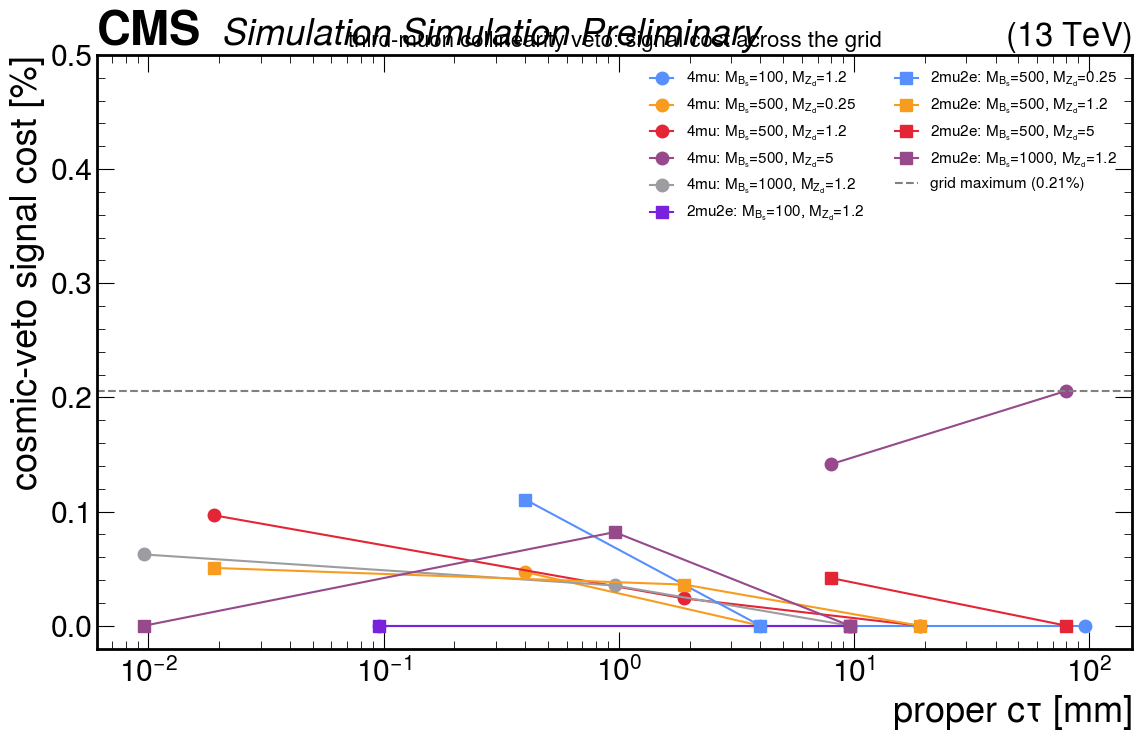

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
mk = {"4mu": "o", "2mu2e": "s"}
for ch in ("4mu", "2mu2e"):
    series = {}
    for mb, mdp, ct, n, tot, frac in COST[ch]:
        series.setdefault((ch, mb, mdp), []).append((ct, 100 * frac))
    for (c, mb, mdp), pts in sorted(series.items()):
        pts.sort()
        ax.plot([p[0] for p in pts], [p[1] for p in pts], mk[ch] + "-", ms=9,
                label=r"%s: $M_{B_s}$=%d, $M_{Z_d}$=%.2g" % (ch, mb, mdp))
ax.axhline(0.206, color="gray", ls="--", label="grid maximum (0.21%)")
ax.set_xscale("log"); ax.set_xlabel(r"proper $c\tau$ [mm]")
ax.set_ylabel("cosmic-veto signal cost [%]")
ax.set_ylim(-0.02, 0.5)
ax.set_title("third-muon collinearity veto: signal cost across the grid", fontsize=16)
ax.legend(fontsize=11, ncol=2)
hep.cms.label("Simulation Preliminary", data=False, ax=ax)
plt.tight_layout(); plt.show()

The veto costs **at most ~0.2% of signal anywhere on the grid** (typically far
less, and exactly zero at most points), with no lifetime trend -- the
signal-preserving behavior a usable cosmic veto needs, and the property the
plain cos alpha cut lacked. Because the tag draws its back-to-back partner from
muons *outside* the two signal lepton-jets, a signal event is not tagged by its
own topology; because it is a kinematic tag, it carries no data-driven scale
factor into the limit.

## What is deferred to the data continuation

MC establishes the signal cost (negligible, above); it cannot establish the
**cosmic rejection**, because there are no cosmics in simulation. The rejection
-- and the evaluation of the vertex-consistency `coll` variant against the
cos alpha blind spot -- is a measurement in a cosmic-enriched data control
region, and is the natural next step for whoever continues this study
(`COSMIC_VERTEX_CONSISTENCY.md` states the two thresholds to decide on: adopt
the extra variable only if it adds rejection at negligible signal cost). The
veto is carried into the search as a cheap, signal-safe hygiene cut whose
rejection is confirmed on data.

## Takeaways

* A **plain back-to-back cut self-vetoes 4mu signal** (the two dark-photon
  lepton-jets are back-to-back); the **third-muon collinearity tag** avoids
  this by drawing its partner from muons outside the two signal lepton-jets.
* Its **signal cost is negligible** -- at most ~0.2% across the mass/lifetime
  grid, zero at most points, no lifetime trend -- the "signal unscathed"
  property a cosmic veto must have.
* The **vertex-consistency `coll` variant** (design note) plugs the residual
  cos alpha blind spot by making large separation cosmic-specific, sparing
  displaced signal.
* **Cosmic rejection is MC-invisible** and is a data-control-region measurement
  -- the data-side continuation of this study.